# Linear Regression

Before building a deep neural network model, start with linear regression using one and several variables.

# Linear regression with one variable

Begin with a single-variable regression to predict `MPG` from `Horsepower`.

Training a model with `tf.keras` typically starts by defining the model architecture. Use a `tf.keras.Sequential` model which represents a sequence of steps.

Let's take a second to fully understand what a sequential model is (and, by extension, tensors) before continuing. Refer to `sequential_models_and_tensors.ipynb` for more......

ALRIGHT! BACK TO IT!

# Basic regression: Predict fuel efficiency

In a regression problem, the aim is to predict the output of a continuous value, like a price or a probability. Contrast this with a classification problem, where the aim is to select a class from a list of classes.

Let's begin you god damn genius.

In [580]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

np.set_printoptions(precision=3, suppress=True)

import tensorflow as tf
import keras
from keras import layers

print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)

TensorFlow version: 2.20.0
Keras version: 3.11.3


## The Auto MPG dataset

### Get the data

First download and import the dataset using pandas:

In [581]:
url = 'http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data'
column_names = ['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight',
                'Acceleration', 'Model Year', 'Origin']

raw_dataset = pd.read_csv(url, names=column_names,
                          na_values='?', comment='\t',
                          sep=' ', skipinitialspace=True)

In [582]:
dataset = raw_dataset.copy()
dataset.tail()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
393,27.0,4,140.0,86.0,2790.0,15.6,82,1
394,44.0,4,97.0,52.0,2130.0,24.6,82,2
395,32.0,4,135.0,84.0,2295.0,11.6,82,1
396,28.0,4,120.0,79.0,2625.0,18.6,82,1
397,31.0,4,119.0,82.0,2720.0,19.4,82,1


### Clean the data

The dataset contains a few unknown values:

In [583]:
dataset.isna().sum()

MPG             0
Cylinders       0
Displacement    0
Horsepower      6
Weight          0
Acceleration    0
Model Year      0
Origin          0
dtype: int64

Drop those rows to keep this initial tutorial simple:

In [584]:
dataset = dataset.dropna()

The `"Origin"` column is categorical, not numeric. So the next step is to one-hot encode the values in the column with `pd.get_dummies`.

**Note:** You can set up the `tf.keras.Model` to do this kind of transformation for you but that's "beyond the scope of this tutorial". Check out [Classify structured data using Keras preprocessing layers](https://www.tensorflow.org/tutorials/structured_data/preprocessing_layers) or [Load CSV data](https://www.tensorflow.org/tutorials/load_data/csv) tutorials. Learn this before your personal application.

In [585]:
dataset["Origin"] = dataset["Origin"].map({1: "USA",
                                           2: "Europe",
                                           3: "Japan"})

dataset = pd.get_dummies(dataset, columns=["Origin"], prefix="", prefix_sep="")
dataset.tail()

# We'll also convert to `float32` to avoid issues we encountered
# the first time we did this tutorial
dataset = dataset.astype('float32')

### Spit the data into training and test sets

Now, split the dataset into a training set and a test set. You will use the test set in the final evaluation of your models.

In [586]:
train_dataset = dataset.sample(frac=0.8, random_state=0)
# This is an incredibly elegant solution that you MUST 
# remember to apply on your own:
# Drop the index of the randomly selected `train_dataset` indices to have the remaining data assigned to `test_dataset`
test_dataset = dataset.drop(train_dataset.index)

### Inspect the data

Review the joint distribution of a few pairs of columns from the training set.

The top row suggests that the fuel efficiency (MPG) is a funciton of all the other parameters.

The other rows indicate they are functions of each other.

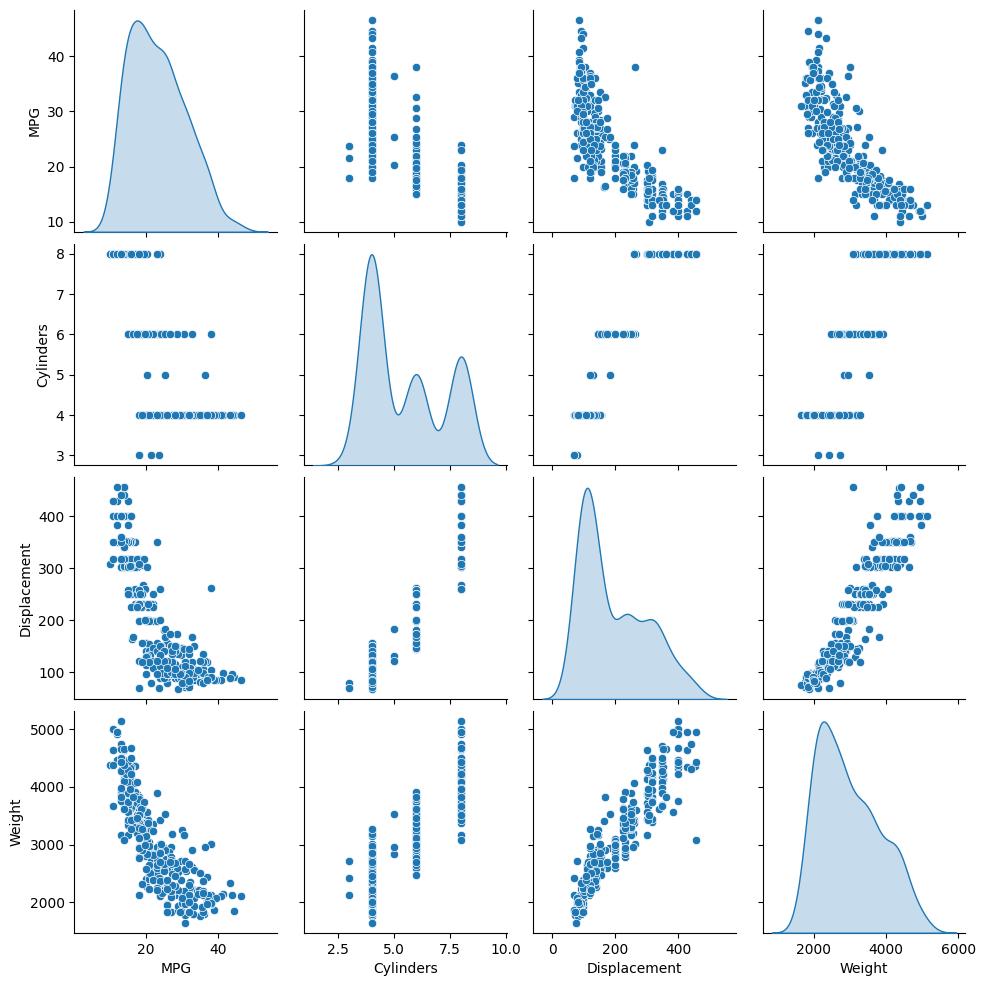

In [587]:
sns.pairplot(train_dataset[["MPG", "Cylinders", "Displacement", "Weight"]], diag_kind="kde")

As a personal note, let's check the data types, since we'll want to convert them to `float32` later.

In [588]:
print(train_dataset.dtypes)

MPG             float32
Cylinders       float32
Displacement    float32
Horsepower      float32
Weight          float32
Acceleration    float32
Model Year      float32
Europe          float32
Japan           float32
USA             float32
dtype: object


Let's also check the overall statistics. Note how each feature covers a very different range:

In [589]:
train_dataset.describe().transpose

<bound method DataFrame.transpose of               MPG   Cylinders  Displacement  ...      Europe       Japan         USA
count  314.000000  314.000000    314.000000  ...  314.000000  314.000000  314.000000
mean    23.310509    5.477707    195.318466  ...    0.178344    0.197452    0.624204
std      7.728652    1.699787    104.331589  ...    0.383413    0.398712    0.485101
min     10.000000    3.000000     68.000000  ...    0.000000    0.000000    0.000000
25%     17.000000    4.000000    105.500000  ...    0.000000    0.000000    0.000000
50%     22.000000    4.000000    151.000000  ...    0.000000    0.000000    1.000000
75%     28.950000    8.000000    265.750000  ...    0.000000    0.000000    1.000000
max     46.599998    8.000000    455.000000  ...    1.000000    1.000000    1.000000

[8 rows x 10 columns]>

## Normalization

In the table of statistics it's easy to see how different the ranges of each feature are:

In [590]:
train_dataset.describe().transpose()[["mean", "std"]]

,mean,std
MPG,23.310509,7.728652
Cylinders,5.477707,1.699787
Displacement,195.318466,104.331589
Horsepower,104.869431,38.096214
Weight,2990.251709,843.898560
Acceleration,15.559236,2.789230
Model Year,75.898087,3.675642
Europe,0.178344,0.383413
Japan,0.197452,0.398712
USA,0.624204,0.485101


We'll also convert the data types to `float32` before continuing to avoid the issues we encountered before learning some other stuff.

### Split features from labels

Separate the target value-the "label"- from the features. This label is the value that you will train the model to predict.

In [591]:
train_features = train_dataset.copy()
test_features = test_dataset.copy()

train_labels = train_features.pop("MPG")
test_labels = test_features.pop("MPG")

It's good practice to normalize features that use different scales and ranges.

As you already know, one reason this is important is because the features are multiplied by the model weights. So, the scale of the outputs and the scale of the gradients are affected by the scale of the inputs.

Although a model *might* converge without feature normalization, normalization makes training much more stable.

**Note:** There is no advantage to normalizing the one-hot features-it's done here for simplicity. Look up more info on preprocessing and follow [this guide](https://www.tensorflow.org/tutorials/structured_data/preprocessing_layers) when you're ready.

### The Normalization layer

The `tf.keras.layers.Normalization` is a clean and simple way to add feature normalization into your model.

The first step is to create the layer.

In [592]:
normalizer = tf.keras.layers.Normalization(axis=1)

Wouldn't we want to normalize the entire dataset way above this code block instead? Wouldn't that make more sense?

Probably a mix of tutorial purposes and probably some other factors I'm not yet aware of.

Then, fit the state of the preprocessing layer to the data by calling `Normalization.adapt`:

In [593]:
normalizer.adapt(np.array(train_features))

The `adapt()` method calculates the mean and variance from the training data and stores them as attributes of the normalizer layer.

In [594]:
print(normalizer.mean.numpy())

[[   5.478  195.318  104.869 2990.252   15.559   75.898    0.178    0.197
     0.624]]


When the layer is called, it returns the input data, with each feature independently normalized:

In [595]:
first = np.array(train_features[:1])

with np.printoptions(precision=2, suppress=True):
    print("First example:", first)
    print()
    print("Normalized:", normalizer(first).numpy())

First example: [[   4.    90.    75.  2125.    14.5   74.     0.     0.     1. ]]

Normalized: [[-0.87 -1.01 -0.79 -1.03 -0.38 -0.52 -0.47 -0.5   0.78]]


## Linear Regression

Before building a deep neural network model, start with linear regression using one and several variables.

### Linear regression with one variable

Begin with a single-variable linear regression to predict `MPG` from `Horsepower`.

Training a model with `tf.keras` typically starts by defining the model architecture. Use a `tf.keras.Sequential` model, which represents a sequence of steps.

There are two steps in your single-variable linear regression model:
* Normalize the `Horsepower` input features using the `tf.keras.layers.Normalization` preprocessing layer.
* Apply a linear transformation to produce 1 output using a linear layer (`tf.keras.layers.Dense`).

The number of inputs can either be set by the `input_shape` argument, or automatically when the model is run for the first time.

First, create a NumPy array made of the `Horsepower` features. Then, instantiate the `tf.keras.layers.Normalization` and fit its state to the `horsepower` data:

In [596]:
horsepower = np.array(train_features["Horsepower"])

horsepower_normalizer = layers.Normalization(input_shape=[1,], axis=None, name="normalization_layer")
horsepower_normalizer.adapt(horsepower)

/Users/christiancamp/Desktop/Learning Machine Learning/An Introduction to Statistical Learning/ml-learning-linear-regression/lin-reg-env/lib/python3.13/site-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Keep in mind the warning in the output above. This was also covered in `sequential_models_and_tensors.ipynb`. Do not forget to apply these practices when doing your own project!

"UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead."

Build the Keras Sequential model:

In [597]:
horsepower_model = tf.keras.Sequential([
    horsepower_normalizer,
    layers.Dense(units=1)
])

horsepower_model.summary()

Model: "sequential_46"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_layer             │ (None, 1)              │             3 │
│ (Normalization)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5 (24.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 3 (16.00 B)

Before continuing, let's see if we can address the warning's concerns and use the input shape parameter correctly.

In [598]:
# Create and adapt the normalizer separately
horsepower_normalizer = layers.Normalization(axis=None)
horsepower_normalizer.adapt(horsepower)

# Then build the model
horsepower_model = keras.Sequential([
    keras.Input(shape=[1,]),
    horsepower_normalizer,
    layers.Dense(units=1)
])

horsepower_model.summary()

Model: "sequential_47"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_41                │ (None, 1)              │             3 │
│ (Normalization)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5 (24.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 3 (16.00 B)

Now let's quickly redefine it using their method just in case the above block somehow causes issues (it probably won't but I'd rather not find out).

We'll also give the layers names for good practice.

In [599]:
horsepower = np.array(train_features["Horsepower"])

horsepower_normalizer = layers.Normalization(input_shape=[1,], axis=None, name="normalization_layer")
horsepower_normalizer.adapt(horsepower)

horsepower_model = tf.keras.Sequential([
    horsepower_normalizer,
    layers.Dense(units=1, name="layer1")
])

horsepower_model.summary()

Model: "sequential_48"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_layer             │ (None, 1)              │             3 │
│ (Normalization)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer1 (Dense)                  │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5 (24.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 3 (16.00 B)

This model will predict `MPG` from `Horsepower`.

Run the untrained model on the first 10 `Horsepower` values. The output won't be good, but notice that it has the expected shape of `(10, 1)`:

In [600]:
horsepower_model.predict(horsepower[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


array([[ 0.056],
       [ 0.031],
       [-0.102],
       [ 0.078],
       [ 0.07 ],
       [ 0.028],
       [ 0.083],
       [ 0.07 ],
       [ 0.018],
       [ 0.031]], dtype=float32)

Once the model is built, configure the training procedure using the Keras `Model.compile` method. The most important arguments to compile are the `loss` and the `optimizer`, since these define what will be optimized (`mean_absolute_error`) and how (using the `tf.keras.optimizers.Adam`).

In [601]:
horsepower_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),
    loss="mean_absolute_error"
)

Use Keras `Model.fit` to execute the training for 100 epochs:

In [602]:
%%time
history = horsepower_model.fit(
    train_features["Horsepower"],
    train_labels,
    epochs=100,
    # Suppress logging
    verbose=0,
    # Calculate validation results on 20 percent of the training data
    validation_split = 0.2
)

CPU times: user 2.32 s, sys: 337 ms, total: 2.66 s
Wall time: 2.3 s


Visualize the model's training progress using the stats stored in the `history` object:

In [603]:
hist = pd.DataFrame(history.history)
hist["epoch"] = history.epoch
hist.tail()

,loss,val_loss,epoch
95,3.801834,4.184985,95
96,3.804904,4.170596,96
97,3.809876,4.168387,97
98,3.805486,4.207905,98
99,3.803223,4.198541,99


In [604]:
def plot_loss(history):
    plt.plot(history.history["loss"], label="loss")
    plt.plot(history.history["val_loss"], label="val_loss")

    plt.ylim([0, 10])

    plt.xlabel("Epoch")
    plt.ylabel("Error (MPG)")

    plt.legend()
    plt.grid(True)

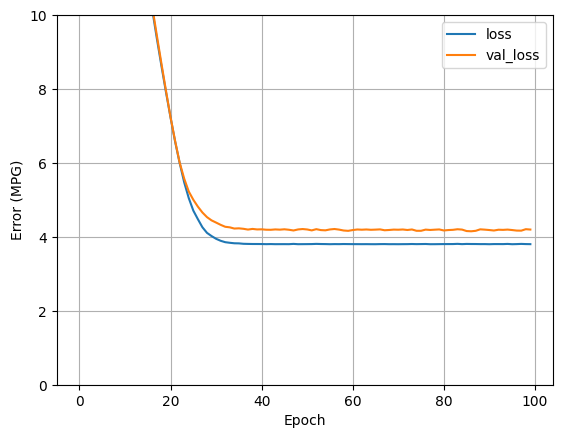

In [605]:
plot_loss(history)

Collect the results on the test set for later:

In [606]:
test_results = {}

# `.evaluate` comes from keras
test_results["horsepower_model"] = horsepower_model.evaluate(
    test_features["Horsepower"],
    test_labels, verbose=0
)

Since this is a single variable regression, it's easy to view the model's predictions as a function of the input:

In [607]:
x = tf.linspace(0.0, 250, 251)
y = horsepower_model.predict(x)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [608]:
def plot_horsepower(x, y):
    plt.scatter(train_features["Horsepower"], train_labels, label="Data")
    plt.plot(x, y, color="k", label="Predictions")
    plt.xlabel("Horsepower")
    plt.ylabel("MPG")
    plt.legend()

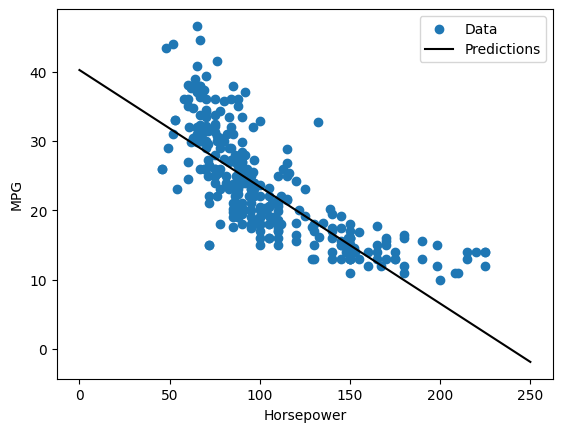

In [609]:
plot_horsepower(x, y)

# Linear Regression with Multiple Inputs

You can use an almost identical setup to make predictions based on multiple inputs. This models still does the same *y = mx + b* except that *m* is a matrix and *x* is a vector.

Create a two-step Keras Sequential model again with the first layer being `normalizer` (`tf.keras.layers.Normalization(axis=1)`) you defined earlier and adapted to the whole dataset:

In [610]:
linear_model = tf.keras.Sequential([
    normalizer,
    layers.Dense(units=1, name="layer1")
])

When you call `Model.predict` on a batch of inputs, it produces `units=1` outputs for each examples:

In [611]:
linear_model.predict(train_features[:10]) # [:10] specifies all features

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


array([[-0.811],
       [-2.237],
       [ 1.595],
       [-1.915],
       [-1.407],
       [-1.23 ],
       [-1.612],
       [-1.84 ],
       [-0.585],
       [-0.645]], dtype=float32)

When you call the model, its weight matrices will be built. Check that the `kernel` weights (the *m* in *y = mx + b) have a shape of `(9, 1)` (9 for the number of input features).

In [612]:
linear_model.layers[1].kernel

<Variable path=sequential_49/layer1/kernel, shape=(9, 1), dtype=float32, value=[[ 0.542]
 [ 0.443]
 [ 0.42 ]
 [-0.51 ]
 [-0.698]
 [-0.452]
 [ 0.727]
 [ 0.366]
 [-0.083]]>

Configure the model with Keras `Model.compile` and traing with `Model.fit` for 100 epochs:

In [613]:
linear_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),
    loss="mean_absolute_error"
)

In [614]:
%%time
history = linear_model.fit(
    train_features,
    train_labels,
    epochs=100,
    # Suppress logging
    verbose=0,
    # Calculate validation results on 20 percent of the training data
    validation_split = 0.2
)

CPU times: user 2.37 s, sys: 341 ms, total: 2.72 s
Wall time: 2.35 s


Using all the inputs in this regression model achieves a much lower training and validation error than the `horsepower_model`, which had one input:

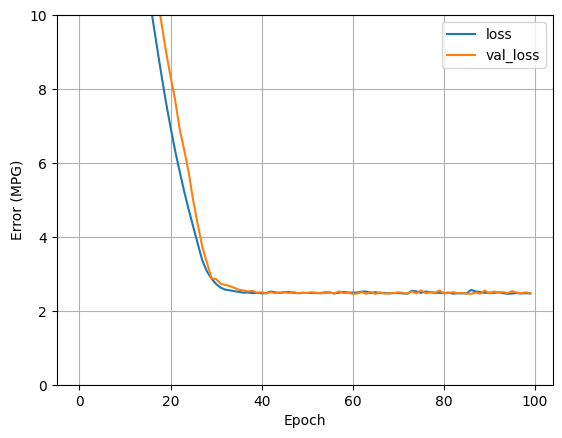

In [615]:
plot_loss(history)

Collect the results on the test set for later:

In [616]:
test_results["linear_model"] = linear_model.evaluate(
    test_features, test_labels, verbose=0
)

# Regression with a Deep Neural Network (DNN)

In the previous section, you implemented two linear models for single and multiple inputs.

Here, you will implement single-input and multiple-input DNN models.

The code is basically the same except the model is expanded to include some "hidden" non-linear layers. the name "hidden" here just means not directly connected to the inputs or the outputs.

These models will contain a few more layers than the linear model:
* The normalization layer, as before.
* Two hidden, non-linear, `Dense` layers with the ReLU (`relu`) activation function nonlinearity.
* A linear `Dense` single-output layer.

Both models will use the same training procedure, to the `compile` method is included in the `build_and_compile_model` function below.

In [617]:
def build_and_compile_model(norm):
    model = keras.Sequential([
        norm,
        layers.Dense(64, activation="relu", name="layer1"),
        layers.Dense(64, activation="relu", name="layer2"),
        layers.Dense(1, name="layer3")
    ])

    model.compile(loss="mean_absolute_error",
                  optimizer=tf.keras.optimizers.Adam(0.001))
    return model

## Regression using a DNN and a single input

Create a DNN model with only `Horsepower` as input and `horsepower_normalizer` as the normalization layer:

In [618]:
dnn_horsepower_model = build_and_compile_model(horsepower_model)

This model has quite a few more trainable parameters than the linear models:

In [619]:
dnn_horsepower_model.summary()

Model: "sequential_50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_48 (Sequential)      │ (None, 1)              │             5 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer1 (Dense)                  │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer2 (Dense)                  │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer3 (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,358 (17.03 KB)

 Trainable params: 4,355 (17.01 KB)

 Non-trainable params: 3 (16.00 B)

Train the model with Keras `Model.fit`:

In [620]:
%%time
history = dnn_horsepower_model.fit(
    train_features["Horsepower"],
    train_labels,
    validation_split=0.2,
    verbose=0,
    epochs=100
)

CPU times: user 2.77 s, sys: 417 ms, total: 3.19 s
Wall time: 2.74 s


This model does slightly better than the linear single-input `horsepower_model`.

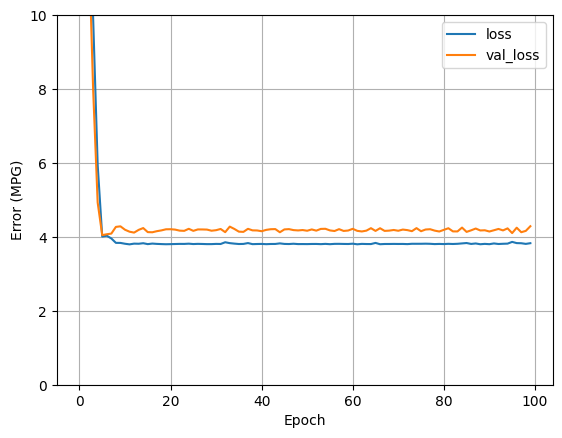

In [621]:
plot_loss(history)

If you plot the predictions as a funciton of `Horsepower`, you should notice how this model takes advantage of the nonlinearity provided by the hidden layers:

In [622]:
x = tf.linspace(0.0, 250, 251)
y = dnn_horsepower_model.predict(x)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


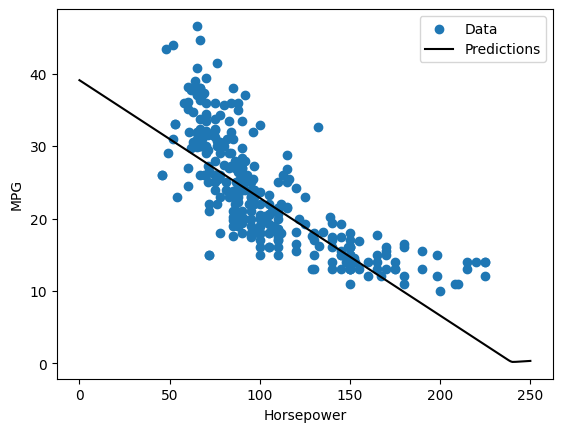

In [623]:
plot_horsepower(x, y)

Collect the results on the test set for later:

In [624]:
test_results["dnn_horsepower_model"] = dnn_horsepower_model.evaluate(
    test_features["Horsepower"], test_labels,
    verbose=0
)

# Regression Using a DNN and Multiple Inputs

Repeat the previous process using all the inputs. The model's performance slightly improves on the validation dataset.

In [625]:
dnn_model = build_and_compile_model(normalizer)
dnn_model.summary()

Model: "sequential_51"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_40                │ (10, 9)                │            19 │
│ (Normalization)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer1 (Dense)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer2 (Dense)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer3 (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19 (80.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 19 (80.00 B)

In [628]:
%%time
history = dnn_model.fit(
    train_features,
    train_labels,
    validation_split=0.2,
    verbose=0, epochs=100)

CPU times: user 2.35 s, sys: 327 ms, total: 2.68 s
Wall time: 2.32 s


In [629]:
dnn_model.summary()

Model: "sequential_51"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_40                │ (None, 9)              │            19 │
│ (Normalization)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer1 (Dense)                  │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer2 (Dense)                  │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer3 (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,616 (57.10 KB)

 Trainable params: 4,865 (19.00 KB)

 Non-trainable params: 19 (80.00 B)

 Optimizer params: 9,732 (38.02 KB)

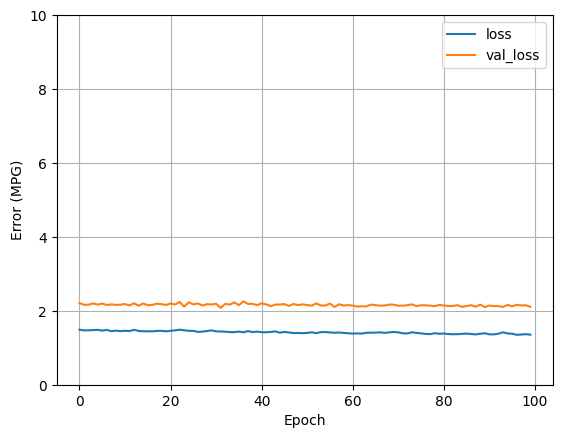

In [630]:
plot_loss(history)

Collect the results on the test set:

In [631]:
test_results["dnn_model"] = dnn_model.evaluate(test_features, test_labels, verbose=0)

# Performance

Since all models have been trained, you can review their test set performance:

In [632]:
pd.DataFrame(test_results, index=["Mean absolute error (MPG)"]).T

,Mean absolute error (MPG)
horsepower_model,3.646402
linear_model,2.449300
dnn_horsepower_model,3.789397
dnn_model,1.668554


These results match the validation error observed during training.

# Make Predictions

You can now make predictions with the `dnn_model` on the test set using Keras `Model.predict` and review the loss:

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


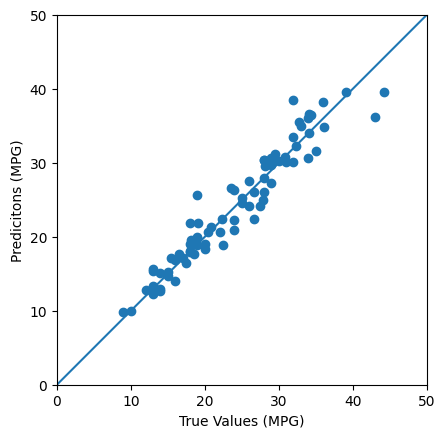

In [634]:
test_predictions = dnn_model.predict(test_features).flatten()

a = plt.axes(aspect="equal")
plt.scatter(test_labels, test_predictions)
plt.xlabel("True Values (MPG)")
plt.ylabel("Predicitons (MPG)")
lims = [0, 50]
plt.xlim(lims)
plt.ylim(lims)
_ = plt.plot(lims, lims)

It appears that model predicts reasonably well.

Now, check the error distribution:

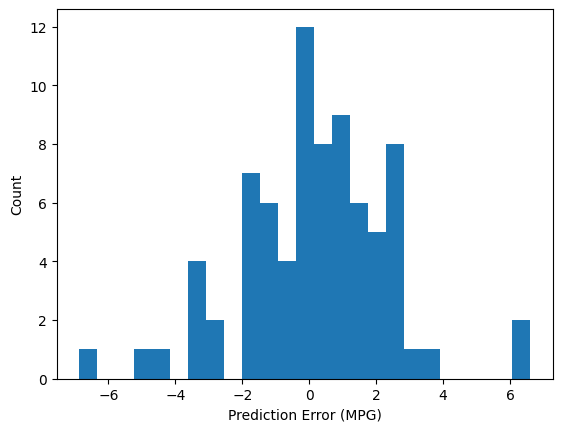

In [635]:
error = test_predictions - test_labels
plt.hist(error, bins=25)
plt.xlabel("Prediction Error (MPG)")
_ = plt.ylabel("Count")

If you're happy with the model, save it for later use with `Model.save`:

In [636]:
dnn_model.save("dnn_model.keras")

If you reload the model, it gives identical output:

In [637]:
reloaded = tf.keras.models.load_model("dnn_model.keras")

test_results["reloaded"] = reloaded.evaluate(
    test_features, test_labels, verbose=0
)

In [638]:
pd.DataFrame(test_results, index=["Mean absolute error (MPG)"]).T

,Mean absolute error (MPG)
horsepower_model,3.646402
linear_model,2.449300
dnn_horsepower_model,3.789397
dnn_model,1.668554
reloaded,1.668554


Congratulations brother. You've reached a major milestone with the completion of this notebook. One. Step. Closer.

I look forward to the day...